# 03 Training Walkthrough

This notebook explains the next step after tokenizer and GPT:

`token ids -> GPT -> loss -> gradients -> optimizer step -> slightly better weights`

The goal is not to reproduce full nanochat pretraining. The real training script has distributed training, checkpointing, evaluation, learning-rate schedules, and custom optimizers.

Here we keep the core idea small enough to see:

- how a token stream becomes `idx` and `targets`
- how `model(idx, targets)` becomes a loss
- how `loss.backward()` creates gradients
- how `optimizer.step()` updates model weights
- how repeated steps can lower loss on a tiny toy pattern

No dataset download is required for this notebook.

In [1]:
from pathlib import Path
import os
import sys

repo_root = Path.cwd()
if not ((repo_root / "nanochat").exists() and (repo_root / "pyproject.toml").exists()):
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "nanochat").exists() and (candidate / "pyproject.toml").exists():
            repo_root = candidate
            break

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

os.environ.setdefault("MPLCONFIGDIR", str(repo_root / ".cache" / "matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

missing = []
for module_name in ["torch", "matplotlib"]:
    try:
        __import__(module_name)
    except Exception:
        missing.append(module_name)

if missing:
    missing_str = ", ".join(missing)
    raise RuntimeError(
        f"Missing dependencies: {missing_str}\n"
        f"Current Python executable: {sys.executable}\n\n"
        "This usually means Jupyter opened the notebook on the wrong kernel.\n"
        "In Jupyter, switch to the `nanochat (.venv)` kernel and rerun this cell.\n\n"
        "If you have not installed that kernel yet, from the repo root run:\n"
        "  uv sync --extra cpu --group dev\n"
        "  source .venv/bin/activate\n"
        "  python -m ipykernel install --user --name nanochat --display-name 'nanochat (.venv)'"
    )

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from nanochat.common import COMPUTE_DTYPE
from nanochat.gpt import GPT, GPTConfig

torch.manual_seed(1337)

print(f"repo_root: {repo_root}")
print(f"python: {sys.executable}")
print(f"torch: {torch.__version__}")
print(f"matplotlib: {plt.matplotlib.__version__}")
print(f"compute dtype: {COMPUTE_DTYPE}")

repo_root: /Users/eugene/Developer/nanochat
python: /Users/eugene/Developer/nanochat/.venv/bin/python
torch: 2.9.1
matplotlib: 3.10.8
compute dtype: torch.float32


## Step 1. The training loop in one picture

After tokenizer and GPT, the central loop is:

```text
1. get token batch
2. split it into inputs and next-token targets
3. run GPT forward pass
4. compute cross-entropy loss
5. run backward pass to compute gradients
6. optimizer updates weights
7. repeat
```

In real nanochat, this is mainly spread across:

- `nanochat/dataloader.py`: builds `x, y` token batches
- `nanochat/gpt.py`: turns `x, y` into loss
- `scripts/base_train.py`: runs backward pass and optimizer steps

The tiny version below keeps the same shape of idea, but uses a small in-memory token pattern.

## Step 2. A token stream becomes `idx` and `targets`

Training does not feed raw text into GPT. It feeds token ids.

For next-token prediction, we take a sequence and shift it by one:

```text
row:     [1, 2, 3, 4, 5]
idx:     [1, 2, 3, 4]
targets: [2, 3, 4, 5]
```

So the model learns:

```text
given 1, predict 2
given 2, predict 3
given 3, predict 4
given 4, predict 5
```

This is the same basic idea used by the real dataloader. The real dataloader fills rows from dataset documents; this toy version fills rows from a repeated pattern.

In [2]:
pattern = torch.tensor([1, 2, 3, 4, 5, 6, 7, 8], dtype=torch.long)


def make_toy_batch(batch_size=2, seq_len=8, offset=0):
    token_stream = pattern.repeat(30)
    rows = []
    for batch_idx in range(batch_size):
        start = (offset + batch_idx * 3) % (len(token_stream) - seq_len - 1)
        rows.append(token_stream[start:start + seq_len + 1])
    rows = torch.stack(rows)

    # Inputs are all tokens except the last one.
    # Targets are all tokens except the first one.
    # contiguous() matters because slicing creates views, while GPT's loss flattens tensors.
    idx = rows[:, :-1].contiguous()
    targets = rows[:, 1:].contiguous()
    return idx, targets, rows


idx, targets, rows = make_toy_batch(batch_size=2, seq_len=8, offset=0)

print("full rows, before shifting:")
print(rows)
print()
print("idx: model input tokens")
print(idx)
print(f"shape = {tuple(idx.shape)}, dtype = {idx.dtype}")
print()
print("targets: next tokens we want the model to predict")
print(targets)
print(f"shape = {tuple(targets.shape)}, dtype = {targets.dtype}")
print()
print("First row as prediction pairs:")
for current_token, next_token in zip(idx[0].tolist(), targets[0].tolist()):
    print(f"  given {current_token}, predict {next_token}")

full rows, before shifting:
tensor([[1, 2, 3, 4, 5, 6, 7, 8, 1],
        [4, 5, 6, 7, 8, 1, 2, 3, 4]])

idx: model input tokens
tensor([[1, 2, 3, 4, 5, 6, 7, 8],
        [4, 5, 6, 7, 8, 1, 2, 3]])
shape = (2, 8), dtype = torch.int64

targets: next tokens we want the model to predict
tensor([[2, 3, 4, 5, 6, 7, 8, 1],
        [5, 6, 7, 8, 1, 2, 3, 4]])
shape = (2, 8), dtype = torch.int64

First row as prediction pairs:
  given 1, predict 2
  given 2, predict 3
  given 3, predict 4
  given 4, predict 5
  given 5, predict 6
  given 6, predict 7
  given 7, predict 8
  given 8, predict 1


## Step 3. Build a tiny GPT

This is the same `GPT` class from `nanochat/gpt.py`, just with tiny dimensions.

One repo-specific constraint still matters: `smear_gate` reads the first 24 embedding channels, so `n_embd` must be at least 24.

In [3]:
cfg = GPTConfig(
    sequence_len=8,
    vocab_size=32,
    n_layer=2,
    n_head=4,
    n_kv_head=2,
    n_embd=24,
    window_pattern="L",
)

model = GPT(cfg)
model.init_weights()
model.train()

print(cfg)
print(f"parameter count: {sum(p.numel() for p in model.parameters()):,}")
print(f"device: {model.get_device()}")

Padding vocab_size from 32 to 64 for efficiency
GPTConfig(sequence_len=8, vocab_size=32, n_layer=2, n_head=4, n_kv_head=2, n_embd=24, window_pattern='L')
parameter count: 16,566
device: cpu


## Step 4. Forward pass: logits vs loss

There are two useful ways to call GPT:

```python
logits = model(idx)
loss = model(idx, targets)
```

When `targets` are missing, GPT returns logits.

When `targets` are provided, GPT computes cross-entropy loss internally and returns one scalar loss.

In [4]:
logits = model(idx)
loss = model(idx, targets)

print(f"logits.shape = {tuple(logits.shape)}")
print(f"loss.shape   = {tuple(loss.shape)}")
print(f"loss value   = {loss.item():.6f}")
print()
print("Interpret logits shape as:")
print("  batch size")
print("  sequence positions")
print("  score for each vocab token")
print()
print("For our batch:")
print(f"  batch size = {logits.shape[0]}")
print(f"  positions  = {logits.shape[1]}")
print(f"  vocab size = {logits.shape[2]}")

logits.shape = (2, 8, 32)
loss.shape   = ()
loss value   = 3.464869

Interpret logits shape as:
  batch size
  sequence positions
  score for each vocab token

For our batch:
  batch size = 2
  positions  = 8
  vocab size = 32


## Step 5. What loss means

For each position, logits are scores for every possible next token.

Cross-entropy asks:

```text
How much probability did the model assign to the correct next token?
```

High confidence on the correct token means lower loss.
Low confidence on the correct token means higher loss.

`GPT.forward(...)` does this internally with `F.cross_entropy(...)` when `targets` are provided.

In [5]:
manual_loss = F.cross_entropy(
    logits.reshape(-1, logits.size(-1)),
    targets.reshape(-1),
    ignore_index=-1,
)

print(f"loss from model(idx, targets): {loss.item():.6f}")
print(f"manual cross-entropy loss:    {manual_loss.item():.6f}")
print()
print("These match because model(idx, targets) is a convenience wrapper around the same idea.")

loss from model(idx, targets): 3.464869
manual cross-entropy loss:    3.464869

These match because model(idx, targets) is a convenience wrapper around the same idea.


## Step 6. Backward pass: loss creates gradients

Before `backward()`, parameters have values but no current gradients.

After:

```python
loss.backward()
```

PyTorch fills `.grad` tensors on model parameters. Those gradients say which direction each weight should move to reduce loss.

In [6]:
model.zero_grad(set_to_none=True)
loss = model(idx, targets)

print("Before backward:")
print(f"  lm_head has grad? {model.lm_head.weight.grad is not None}")
print(f"  wte has grad?     {model.transformer.wte.weight.grad is not None}")
print()

loss.backward()

checks = [
    ("token embedding table / wte", model.transformer.wte.weight),
    ("lm_head", model.lm_head.weight),
    ("first attention output projection", model.transformer.h[0].attn.c_proj.weight),
    ("smear_lambda", model.smear_lambda),
]

print("After backward:")
for name, param in checks:
    grad_norm = None if param.grad is None else param.grad.norm().item()
    print(f"  {name:34s} grad norm = {grad_norm:.8f}")

Before backward:
  lm_head has grad? False
  wte has grad?     False

After backward:
  token embedding table / wte        grad norm = 0.00222162
  lm_head                            grad norm = 1.70046270
  first attention output projection  grad norm = 0.00336934
  smear_lambda                       grad norm = 0.00070072


## Step 7. Optimizer step: gradients update weights

`backward()` only computes gradients. It does not update the model by itself.

The actual weight change happens here:

```python
optimizer.step()
```

The real `base_train.py` uses `model.setup_optimizer(...)`, which creates nanochat's custom parameter groups. For this learning notebook, plain `AdamW` is enough to show the core mechanism.

In [7]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3)

model.zero_grad(set_to_none=True)
loss_before = model(idx, targets)

tracked_weight_before = model.lm_head.weight.detach().clone()
loss_before.backward()
optimizer.step()
model.zero_grad(set_to_none=True)

tracked_weight_after = model.lm_head.weight.detach().clone()
weight_change = (tracked_weight_after - tracked_weight_before).norm().item()
loss_after_one_step = model(idx, targets).item()

print(f"loss before optimizer step: {loss_before.item():.6f}")
print(f"loss after one step:        {loss_after_one_step:.6f}")
print(f"lm_head weight change norm: {weight_change:.8f}")
print()
print("One step may improve a little, a lot, or even briefly get worse.")
print("Training is about many small updates, not one magic update.")

loss before optimizer step: 3.464869
loss after one step:        3.392994
lm_head weight change norm: 0.08313816

One step may improve a little, a lot, or even briefly get worse.
Training is about many small updates, not one magic update.


## Step 8. Mini training loop

Now we repeat the same operation many times on the toy pattern:

```text
make batch -> loss -> backward -> optimizer step -> zero gradients
```

Because the data pattern is extremely simple, the tiny model should quickly learn it.

Padding vocab_size from 32 to 64 for efficiency
first loss: 3.464869
last loss:  0.113442

A lower loss means the model is assigning more probability to the correct next tokens.


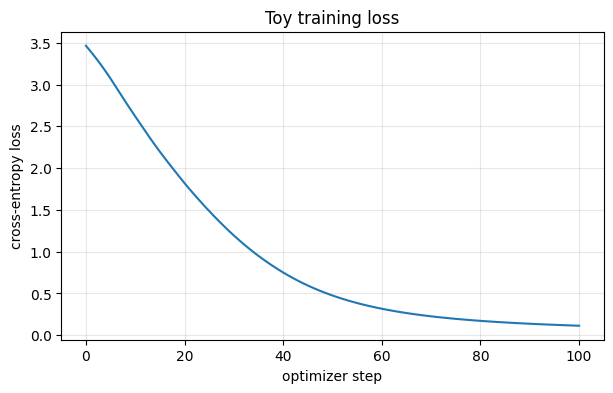

In [8]:
torch.manual_seed(1337)

train_model = GPT(cfg)
train_model.init_weights()
train_model.train()
train_optimizer = torch.optim.AdamW(train_model.parameters(), lr=3e-3)

losses = []
num_steps = 101

for step in range(num_steps):
    batch_idx, batch_targets, _ = make_toy_batch(batch_size=4, seq_len=8, offset=step)
    train_loss = train_model(batch_idx, batch_targets)
    losses.append(train_loss.item())

    train_optimizer.zero_grad(set_to_none=True)
    train_loss.backward()
    train_optimizer.step()

print(f"first loss: {losses[0]:.6f}")
print(f"last loss:  {losses[-1]:.6f}")
print()
print("A lower loss means the model is assigning more probability to the correct next tokens.")

plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.title("Toy training loss")
plt.xlabel("optimizer step")
plt.ylabel("cross-entropy loss")
plt.grid(True, alpha=0.3)
plt.show()

## Step 9. How this maps to `scripts/base_train.py`

The real training script is bigger, but the core loop is the same.

Toy notebook:

```python
idx, targets = make_toy_batch(...)
loss = model(idx, targets)
loss.backward()
optimizer.step()
model.zero_grad(set_to_none=True)
```

Real nanochat pretraining:

```python
x, y, dataloader_state_dict = next(train_loader)
loss = model(x, y)
loss.backward()
optimizer.step()
model.zero_grad(set_to_none=True)
```

The extra real-world pieces are important, but they are wrappers around this core:

- gradient accumulation: split a large batch into smaller micro-batches
- LR schedule: change learning rate over time
- custom optimizer groups: different parameter types get different optimizer settings
- eval loop: measure validation loss without updating weights
- checkpoints: save model/optimizer/dataloader state so training can resume
- distributed training: many GPUs process different batches together

## Step 10. What to learn after this

After this notebook, the next best files to read are:

- `nanochat/dataloader.py`: how real text documents are packed into `x, y`
- `scripts/base_train.py`: the full pretraining loop
- `nanochat/gpt.py` `setup_optimizer(...)`: how nanochat groups parameters for optimization
- `nanochat/loss_eval.py`: how validation loss is measured
- `scripts/chat_sft.py`: how the base model is trained to act more like a chat assistant

The most important bridge is now complete:

`tokenizer -> token ids -> GPT -> loss -> gradients -> optimizer step`

## Takeaways

- `idx` and `targets` are shifted versions of the same token row.
- `model(idx)` returns logits; `model(idx, targets)` returns loss.
- Loss is the training signal: lower means better next-token predictions.
- `loss.backward()` computes gradients; `optimizer.step()` changes weights.
- Full nanochat training adds scale, speed, checkpointing, eval, and distributed execution around this same small loop.